In [1]:
#이 코드는 1열 freq, 2열 Z, 3열 phase로 구성된 csv 파일을 읽어서 Nyquist plot을 그리는 코드입니다.
#또한 폴더 뒤에 converted_를 붙여서 저장합니다. Hz-R-X로 구성된 csv파일로 따로 저장해줍니다.

In [2]:
import glob
import os
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# ====== 1. 원본 CSV 폴더 경로 설정 ======
folder_path = r"C:\Users\user\Desktop\Gibeom\1. HI Lab\0. Projects\0. On going\3. [Lead] ionic DC-TENG\0. 실험자료\9. Revision\260707_LCR 2차\csv\Zdeg"

# ====== 3. Nyquist plot에 사용할 주파수 범위 설정 ======
freq_min = 20
freq_max = 2_000_000

# Plot range
# `X_range`/`Y_range`도 함께 지원하도록 아래에서 정규화합니다.
x_range = (-10, 800)
x_range = None
y_range = (-100, 2000)
y_range = None

# Plot size is fixed regardless of axis range.
plot_figsize = (7, 6)

원본 폴더: C:\Users\user\Desktop\Gibeom\1. HI Lab\0. Projects\0. On going\3. [Lead] ionic DC-TENG\0. 실험자료\9. Revision\260707_LCR 2차\csv\Zdeg
저장 폴더: C:\Users\user\Desktop\Gibeom\1. HI Lab\0. Projects\0. On going\3. [Lead] ionic DC-TENG\0. 실험자료\9. Revision\260707_LCR 2차\csv\Zdeg_Nyquist
대상 파일 수: 29
모든 CSV 파일이 3열 형식임을 확인했습니다.

Processing: 0M_40RH_Zdeg (1).csv
  -> 저장 완료: C:\Users\user\Desktop\Gibeom\1. HI Lab\0. Projects\0. On going\3. [Lead] ionic DC-TENG\0. 실험자료\9. Revision\260707_LCR 2차\csv\Zdeg_Nyquist\0M_40RH_Zdeg (1).csv


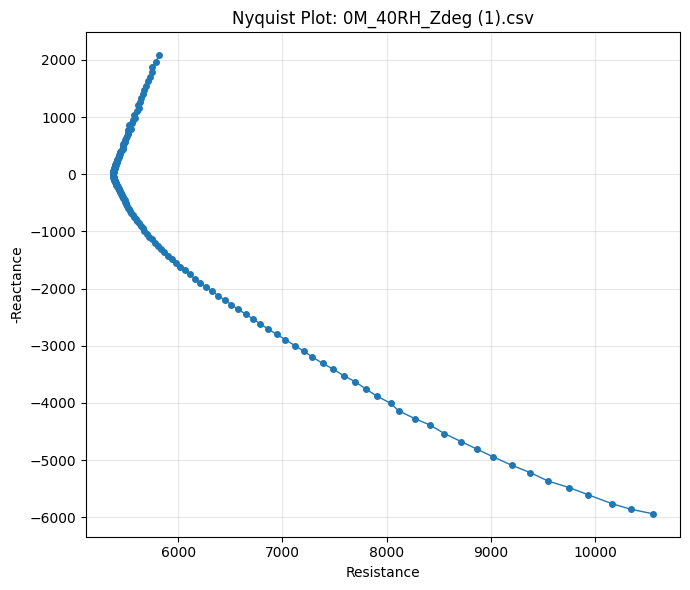

Processing: 0M_40RH_Zdeg (2).csv
  -> 저장 완료: C:\Users\user\Desktop\Gibeom\1. HI Lab\0. Projects\0. On going\3. [Lead] ionic DC-TENG\0. 실험자료\9. Revision\260707_LCR 2차\csv\Zdeg_Nyquist\0M_40RH_Zdeg (2).csv


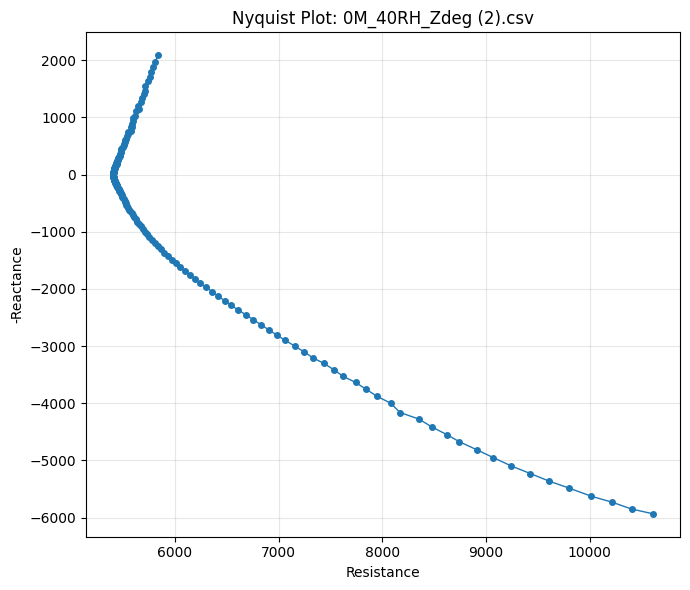

Processing: 0M_40RH_Zdeg (3).csv
  -> 저장 완료: C:\Users\user\Desktop\Gibeom\1. HI Lab\0. Projects\0. On going\3. [Lead] ionic DC-TENG\0. 실험자료\9. Revision\260707_LCR 2차\csv\Zdeg_Nyquist\0M_40RH_Zdeg (3).csv


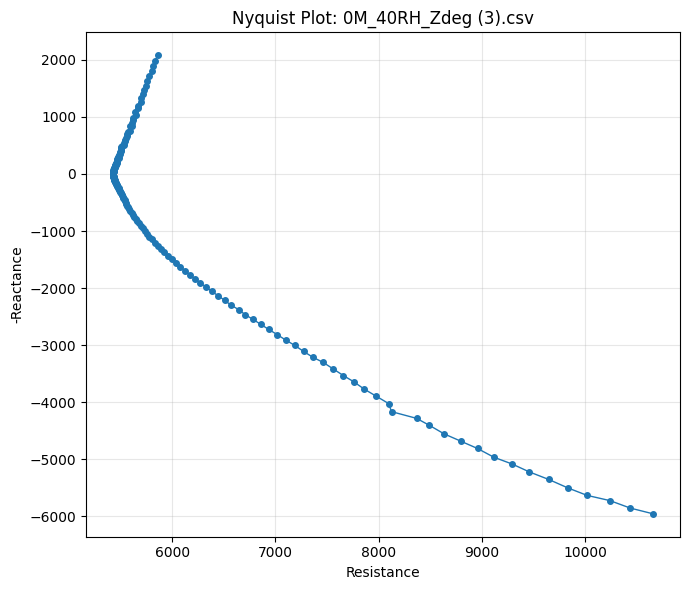

Processing: 0M_60RH_Zdeg (1).csv
  -> 저장 완료: C:\Users\user\Desktop\Gibeom\1. HI Lab\0. Projects\0. On going\3. [Lead] ionic DC-TENG\0. 실험자료\9. Revision\260707_LCR 2차\csv\Zdeg_Nyquist\0M_60RH_Zdeg (1).csv


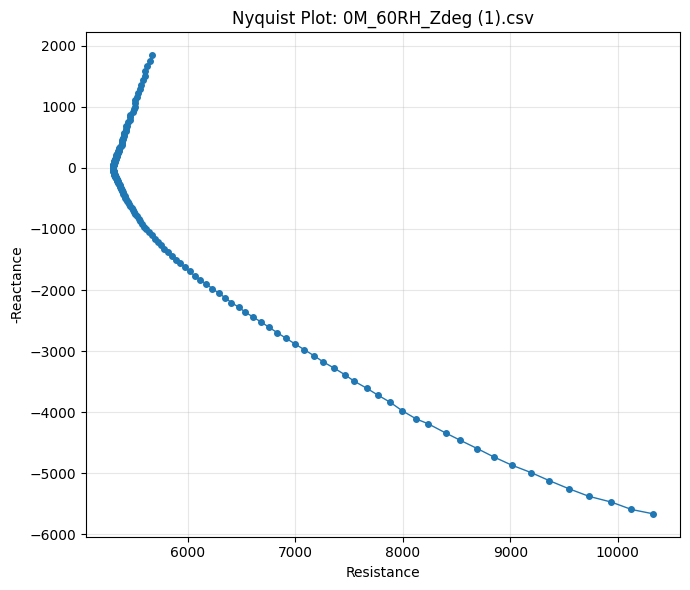

Processing: 0M_60RH_Zdeg (2).csv
  -> 저장 완료: C:\Users\user\Desktop\Gibeom\1. HI Lab\0. Projects\0. On going\3. [Lead] ionic DC-TENG\0. 실험자료\9. Revision\260707_LCR 2차\csv\Zdeg_Nyquist\0M_60RH_Zdeg (2).csv


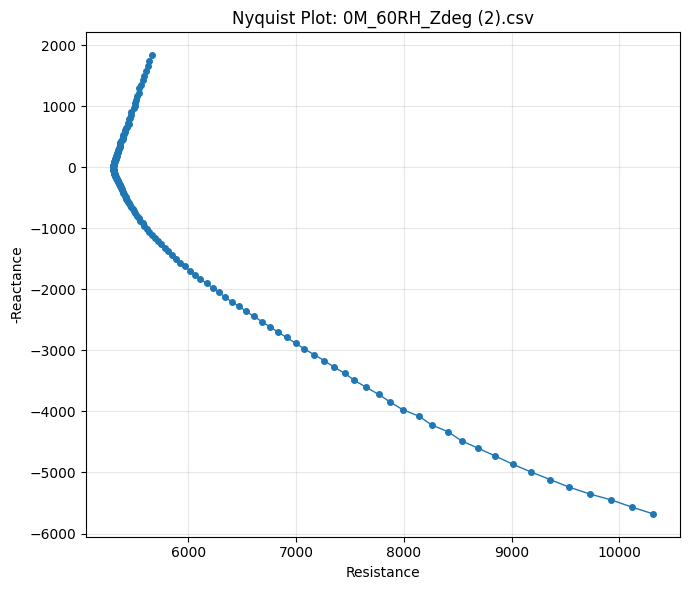

Processing: 0M_60RH_Zdeg (3).csv
  -> 저장 완료: C:\Users\user\Desktop\Gibeom\1. HI Lab\0. Projects\0. On going\3. [Lead] ionic DC-TENG\0. 실험자료\9. Revision\260707_LCR 2차\csv\Zdeg_Nyquist\0M_60RH_Zdeg (3).csv


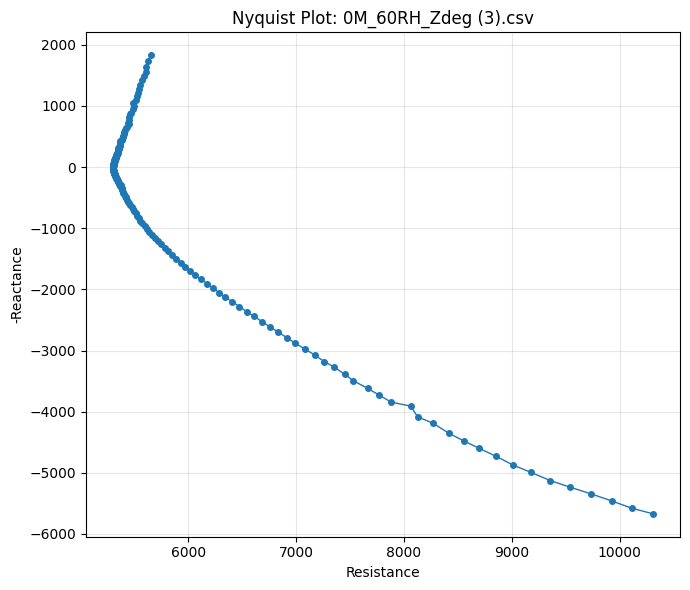

Processing: 0M_80RH_Zdeg (1).csv
  -> 저장 완료: C:\Users\user\Desktop\Gibeom\1. HI Lab\0. Projects\0. On going\3. [Lead] ionic DC-TENG\0. 실험자료\9. Revision\260707_LCR 2차\csv\Zdeg_Nyquist\0M_80RH_Zdeg (1).csv


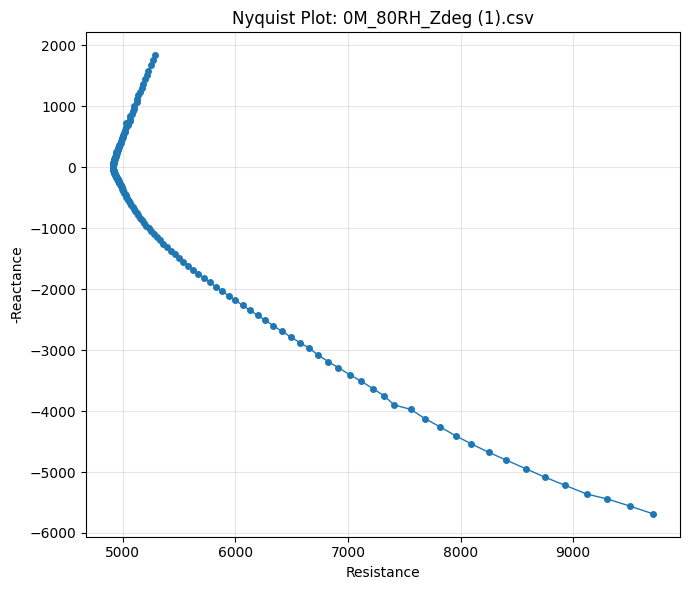

Processing: 0M_80RH_Zdeg (2).csv
  -> 저장 완료: C:\Users\user\Desktop\Gibeom\1. HI Lab\0. Projects\0. On going\3. [Lead] ionic DC-TENG\0. 실험자료\9. Revision\260707_LCR 2차\csv\Zdeg_Nyquist\0M_80RH_Zdeg (2).csv


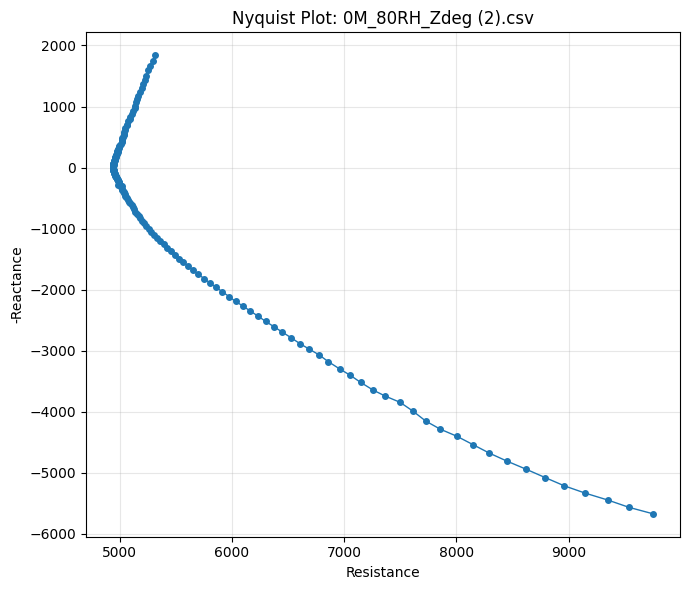

Processing: 0M_80RH_Zdeg (3).csv
  -> 저장 완료: C:\Users\user\Desktop\Gibeom\1. HI Lab\0. Projects\0. On going\3. [Lead] ionic DC-TENG\0. 실험자료\9. Revision\260707_LCR 2차\csv\Zdeg_Nyquist\0M_80RH_Zdeg (3).csv


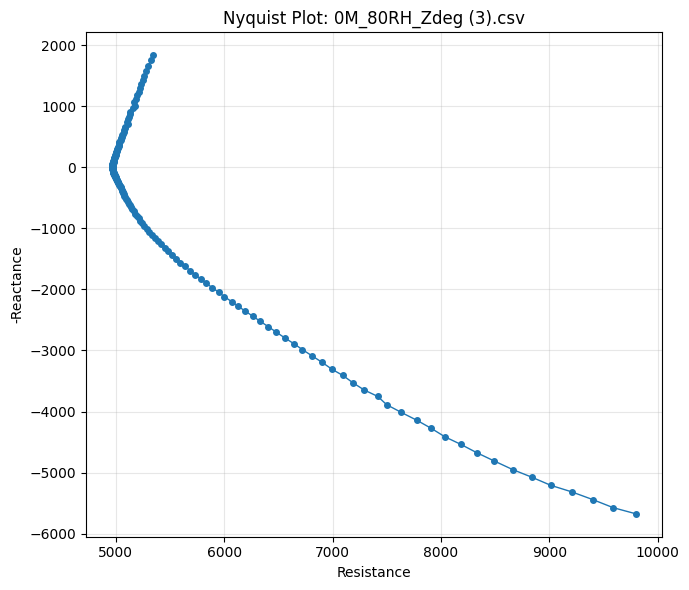

Processing: 1M_40RH_Zdeg (1).csv
  -> 저장 완료: C:\Users\user\Desktop\Gibeom\1. HI Lab\0. Projects\0. On going\3. [Lead] ionic DC-TENG\0. 실험자료\9. Revision\260707_LCR 2차\csv\Zdeg_Nyquist\1M_40RH_Zdeg (1).csv


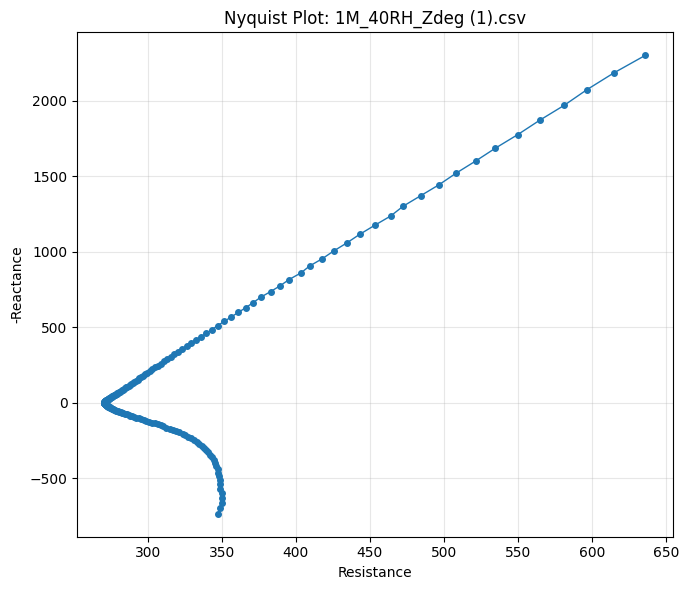

Processing: 1M_40RH_Zdeg (2).csv
  -> 저장 완료: C:\Users\user\Desktop\Gibeom\1. HI Lab\0. Projects\0. On going\3. [Lead] ionic DC-TENG\0. 실험자료\9. Revision\260707_LCR 2차\csv\Zdeg_Nyquist\1M_40RH_Zdeg (2).csv


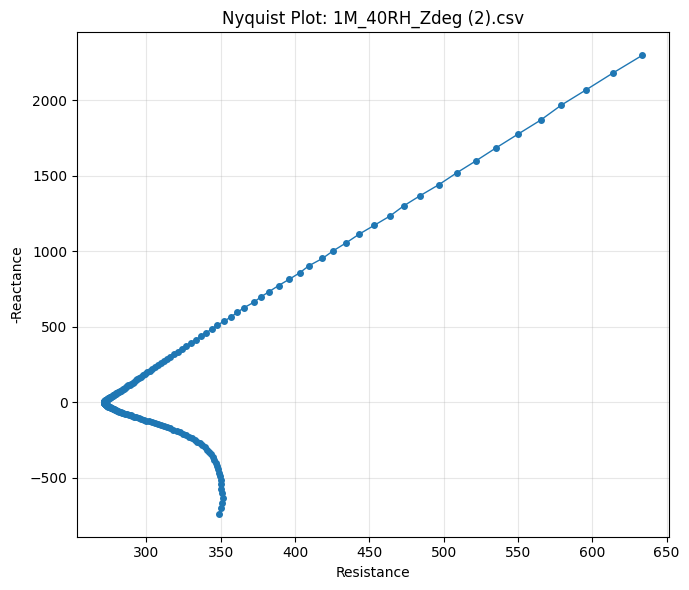

Processing: 1M_40RH_Zdeg (3).csv
  -> 저장 완료: C:\Users\user\Desktop\Gibeom\1. HI Lab\0. Projects\0. On going\3. [Lead] ionic DC-TENG\0. 실험자료\9. Revision\260707_LCR 2차\csv\Zdeg_Nyquist\1M_40RH_Zdeg (3).csv


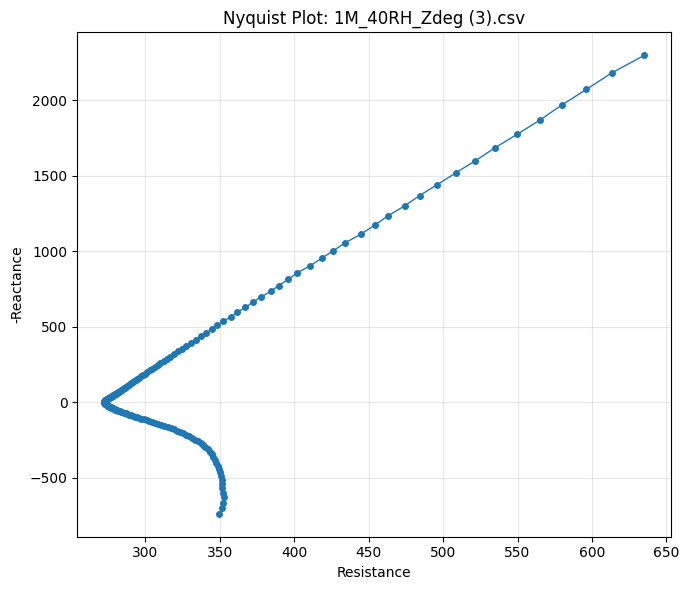

Processing: 1M_60RH_Zdeg (1).csv
  -> 저장 완료: C:\Users\user\Desktop\Gibeom\1. HI Lab\0. Projects\0. On going\3. [Lead] ionic DC-TENG\0. 실험자료\9. Revision\260707_LCR 2차\csv\Zdeg_Nyquist\1M_60RH_Zdeg (1).csv


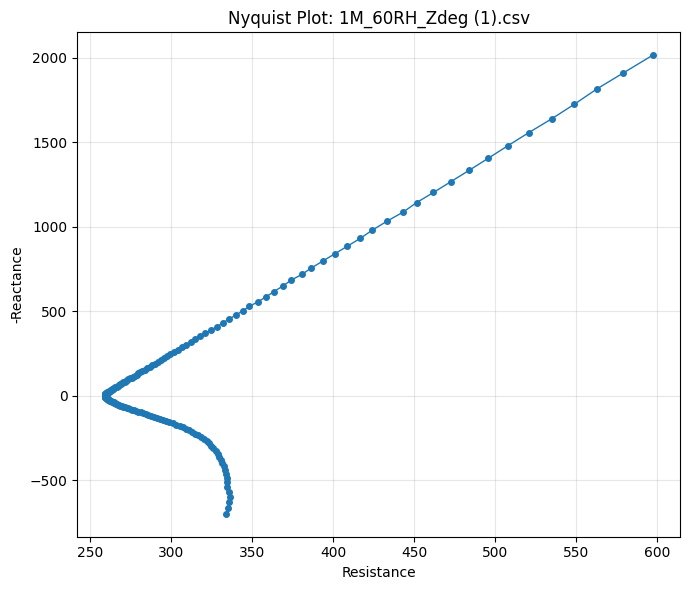

Processing: 1M_60RH_Zdeg (2).csv
  -> 저장 완료: C:\Users\user\Desktop\Gibeom\1. HI Lab\0. Projects\0. On going\3. [Lead] ionic DC-TENG\0. 실험자료\9. Revision\260707_LCR 2차\csv\Zdeg_Nyquist\1M_60RH_Zdeg (2).csv


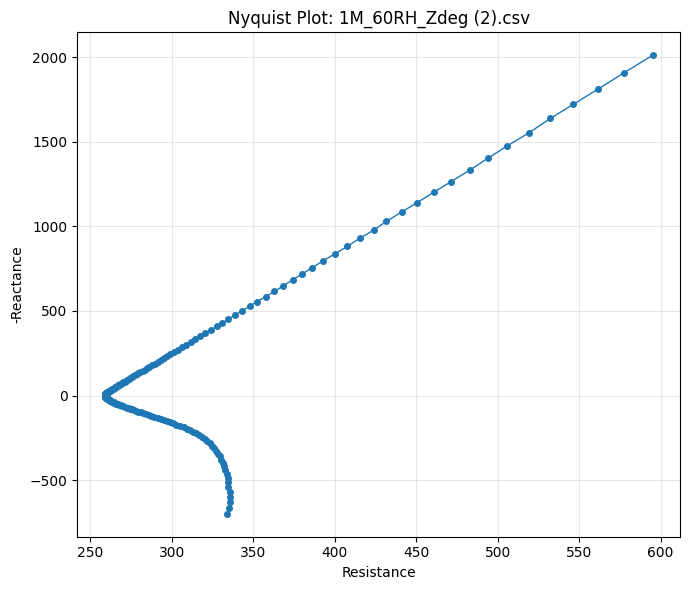

Processing: 1M_60RH_Zdeg (3).csv
  -> 저장 완료: C:\Users\user\Desktop\Gibeom\1. HI Lab\0. Projects\0. On going\3. [Lead] ionic DC-TENG\0. 실험자료\9. Revision\260707_LCR 2차\csv\Zdeg_Nyquist\1M_60RH_Zdeg (3).csv


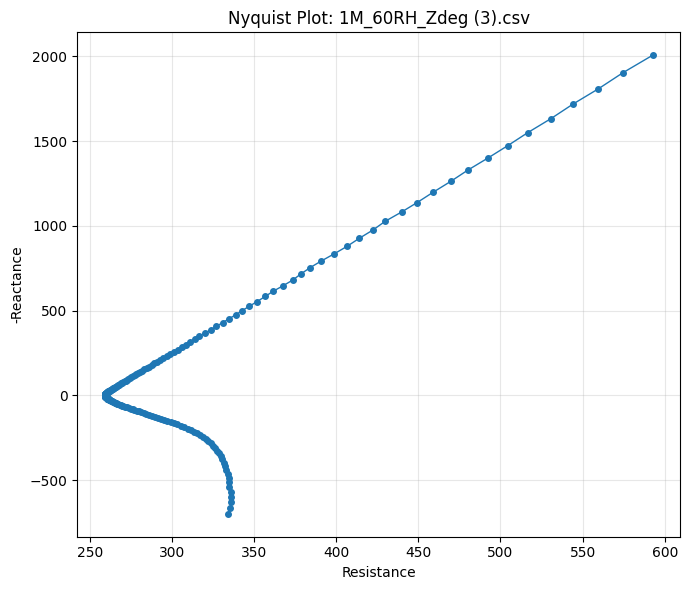

Processing: 1M_80RH_Zdeg (1).csv
  -> 저장 완료: C:\Users\user\Desktop\Gibeom\1. HI Lab\0. Projects\0. On going\3. [Lead] ionic DC-TENG\0. 실험자료\9. Revision\260707_LCR 2차\csv\Zdeg_Nyquist\1M_80RH_Zdeg (1).csv


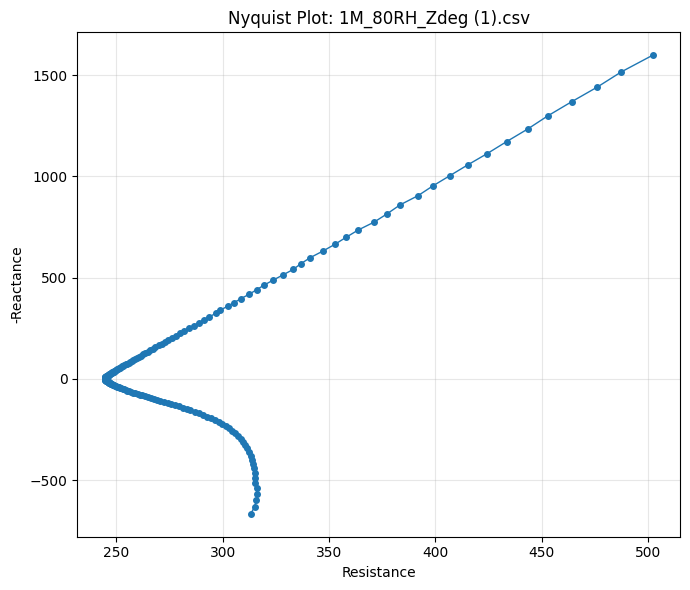

Processing: 1M_80RH_Zdeg (2).csv
  -> 저장 완료: C:\Users\user\Desktop\Gibeom\1. HI Lab\0. Projects\0. On going\3. [Lead] ionic DC-TENG\0. 실험자료\9. Revision\260707_LCR 2차\csv\Zdeg_Nyquist\1M_80RH_Zdeg (2).csv


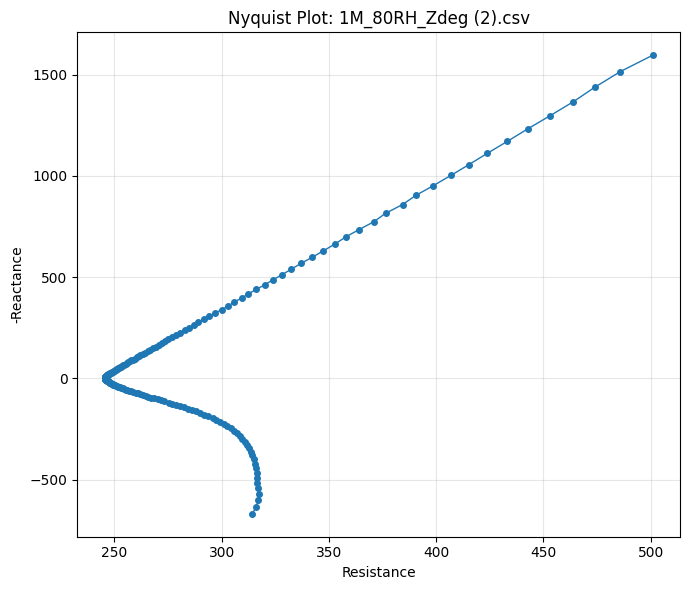

Processing: 1M_80RH_Zdeg (3).csv
  -> 저장 완료: C:\Users\user\Desktop\Gibeom\1. HI Lab\0. Projects\0. On going\3. [Lead] ionic DC-TENG\0. 실험자료\9. Revision\260707_LCR 2차\csv\Zdeg_Nyquist\1M_80RH_Zdeg (3).csv


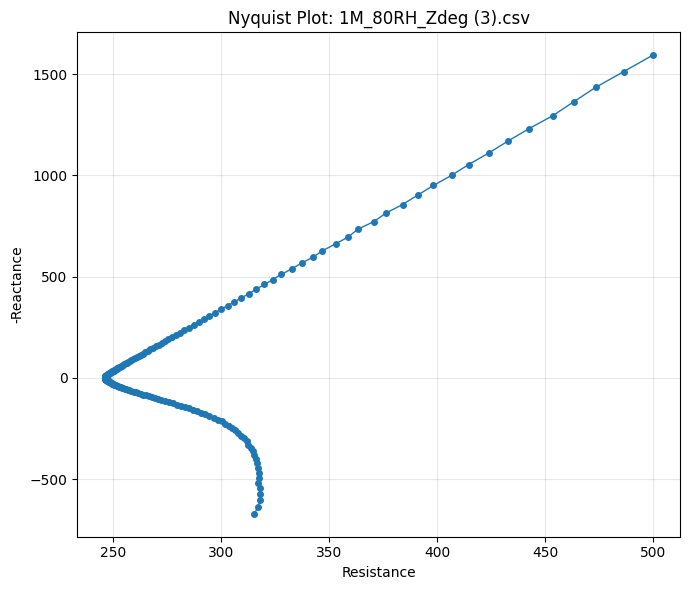

Processing: 2nd Try_0M_60RH_Zdeg (1).csv
  -> 저장 완료: C:\Users\user\Desktop\Gibeom\1. HI Lab\0. Projects\0. On going\3. [Lead] ionic DC-TENG\0. 실험자료\9. Revision\260707_LCR 2차\csv\Zdeg_Nyquist\2nd Try_0M_60RH_Zdeg (1).csv


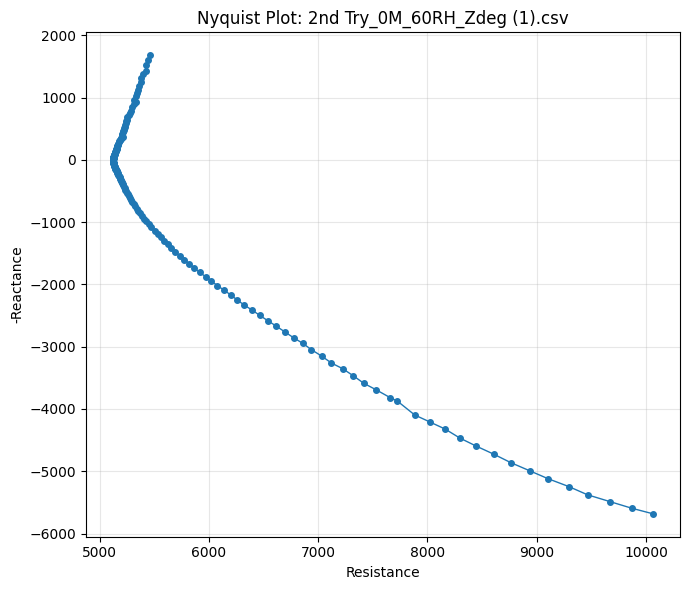

Processing: 2nd Try_0M_60RH_Zdeg (2).csv
  -> 저장 완료: C:\Users\user\Desktop\Gibeom\1. HI Lab\0. Projects\0. On going\3. [Lead] ionic DC-TENG\0. 실험자료\9. Revision\260707_LCR 2차\csv\Zdeg_Nyquist\2nd Try_0M_60RH_Zdeg (2).csv


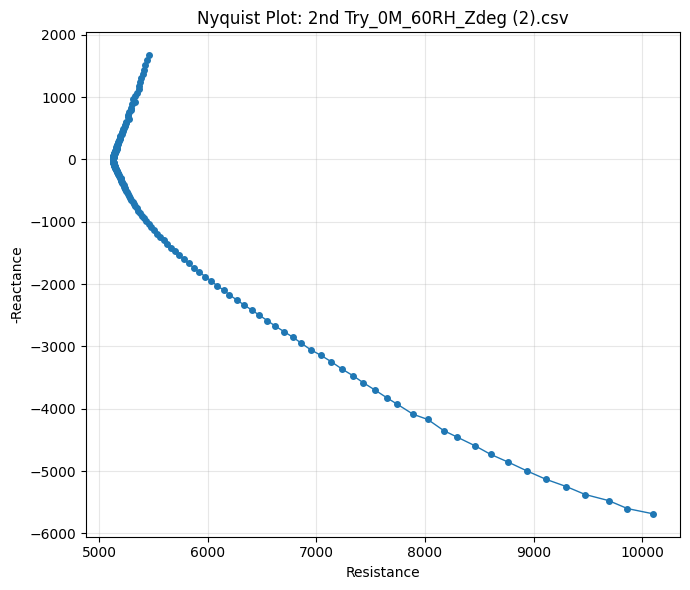

Processing: 2nd Try_0M_80RH_Zdeg (1).csv
  -> 저장 완료: C:\Users\user\Desktop\Gibeom\1. HI Lab\0. Projects\0. On going\3. [Lead] ionic DC-TENG\0. 실험자료\9. Revision\260707_LCR 2차\csv\Zdeg_Nyquist\2nd Try_0M_80RH_Zdeg (1).csv


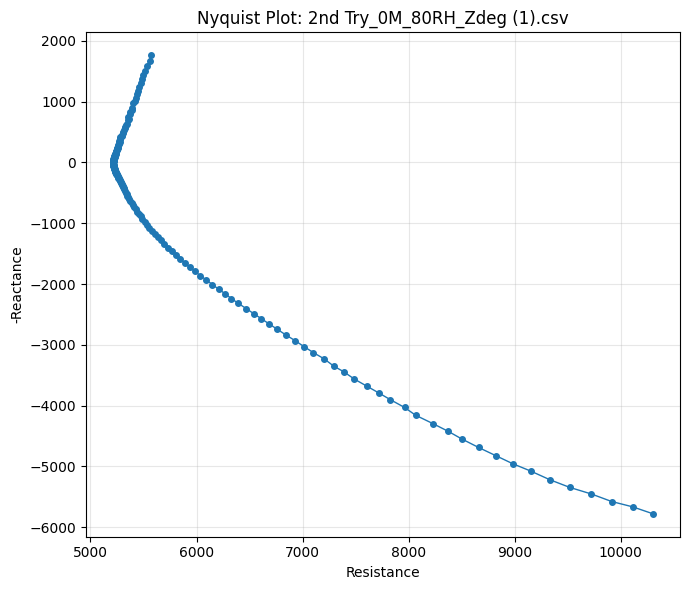

Processing: 2nd Try_0M_80RH_Zdeg (2).csv
  -> 저장 완료: C:\Users\user\Desktop\Gibeom\1. HI Lab\0. Projects\0. On going\3. [Lead] ionic DC-TENG\0. 실험자료\9. Revision\260707_LCR 2차\csv\Zdeg_Nyquist\2nd Try_0M_80RH_Zdeg (2).csv


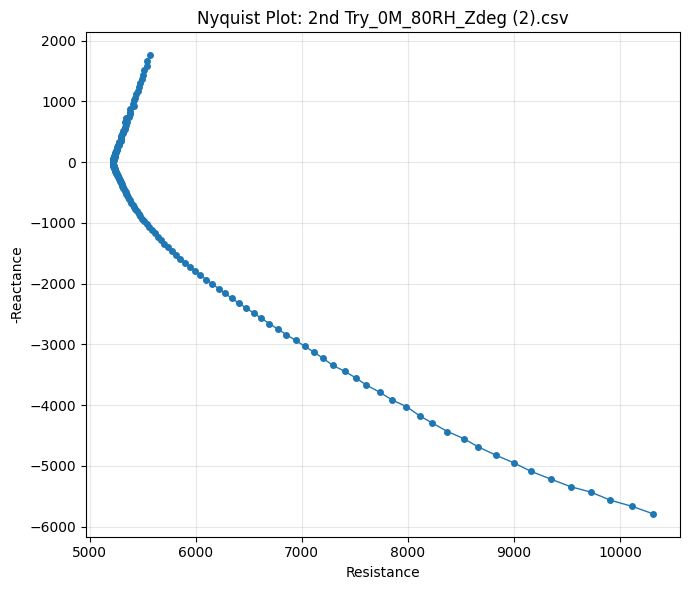

Processing: 2nd Try_0M_80RH_Zdeg (3).csv
  -> 저장 완료: C:\Users\user\Desktop\Gibeom\1. HI Lab\0. Projects\0. On going\3. [Lead] ionic DC-TENG\0. 실험자료\9. Revision\260707_LCR 2차\csv\Zdeg_Nyquist\2nd Try_0M_80RH_Zdeg (3).csv


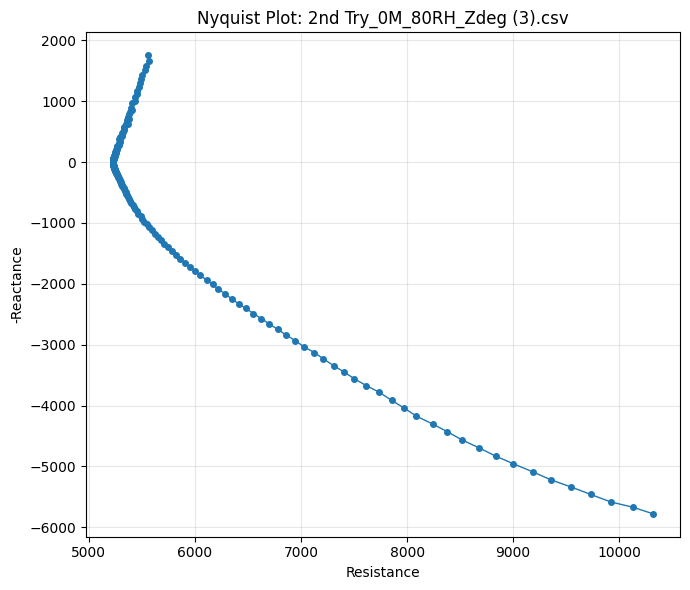

Processing: 2nd Try_1M_60RH_Zdeg (1).csv
  -> 저장 완료: C:\Users\user\Desktop\Gibeom\1. HI Lab\0. Projects\0. On going\3. [Lead] ionic DC-TENG\0. 실험자료\9. Revision\260707_LCR 2차\csv\Zdeg_Nyquist\2nd Try_1M_60RH_Zdeg (1).csv


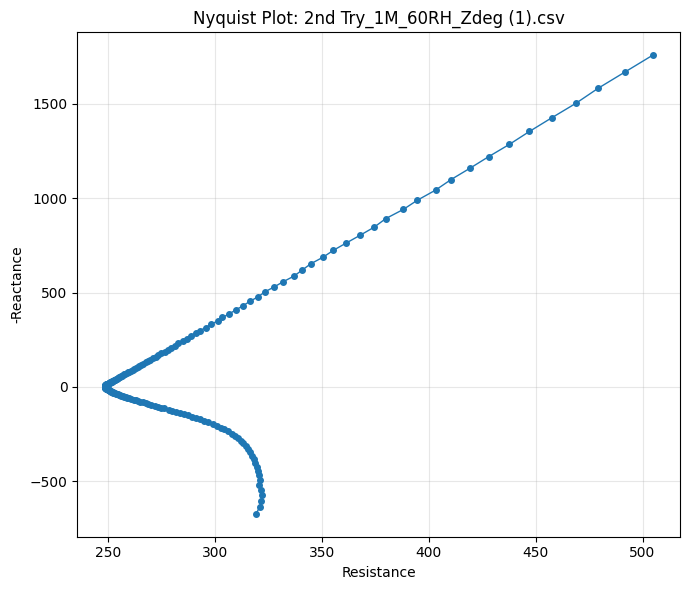

Processing: 2nd Try_1M_60RH_Zdeg (2).csv
  -> 저장 완료: C:\Users\user\Desktop\Gibeom\1. HI Lab\0. Projects\0. On going\3. [Lead] ionic DC-TENG\0. 실험자료\9. Revision\260707_LCR 2차\csv\Zdeg_Nyquist\2nd Try_1M_60RH_Zdeg (2).csv


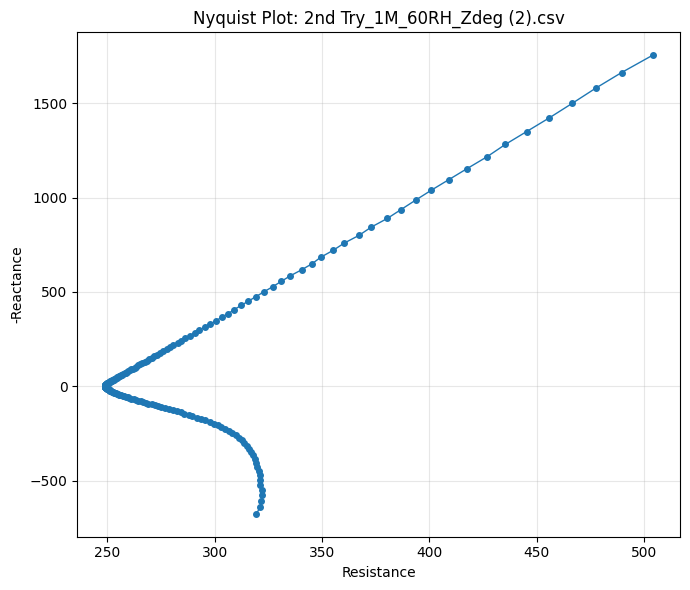

Processing: 2nd Try_1M_60RH_Zdeg (3).csv
  -> 저장 완료: C:\Users\user\Desktop\Gibeom\1. HI Lab\0. Projects\0. On going\3. [Lead] ionic DC-TENG\0. 실험자료\9. Revision\260707_LCR 2차\csv\Zdeg_Nyquist\2nd Try_1M_60RH_Zdeg (3).csv


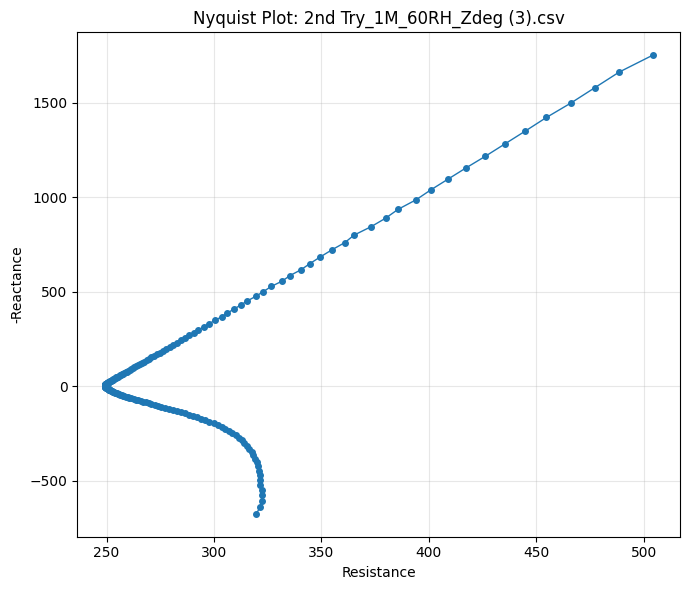

Processing: 2nd Try_1M_80RH_Zdeg (1).csv
  -> 저장 완료: C:\Users\user\Desktop\Gibeom\1. HI Lab\0. Projects\0. On going\3. [Lead] ionic DC-TENG\0. 실험자료\9. Revision\260707_LCR 2차\csv\Zdeg_Nyquist\2nd Try_1M_80RH_Zdeg (1).csv


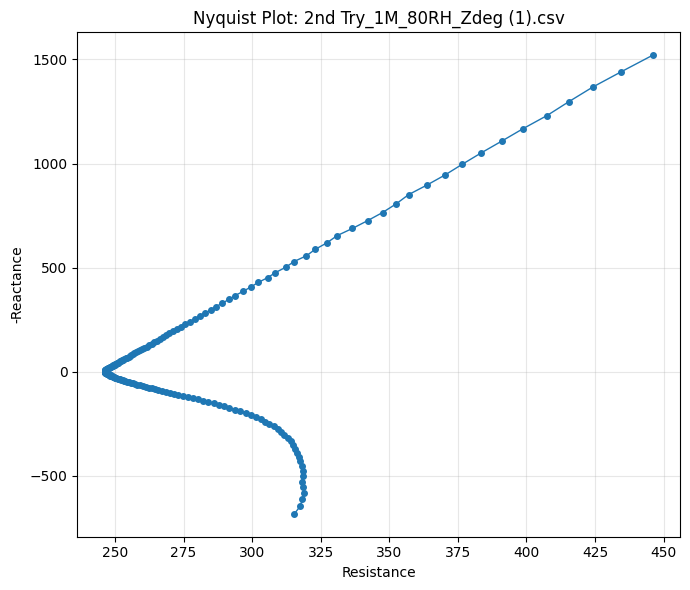

Processing: 2nd Try_1M_80RH_Zdeg (2).csv
  -> 저장 완료: C:\Users\user\Desktop\Gibeom\1. HI Lab\0. Projects\0. On going\3. [Lead] ionic DC-TENG\0. 실험자료\9. Revision\260707_LCR 2차\csv\Zdeg_Nyquist\2nd Try_1M_80RH_Zdeg (2).csv


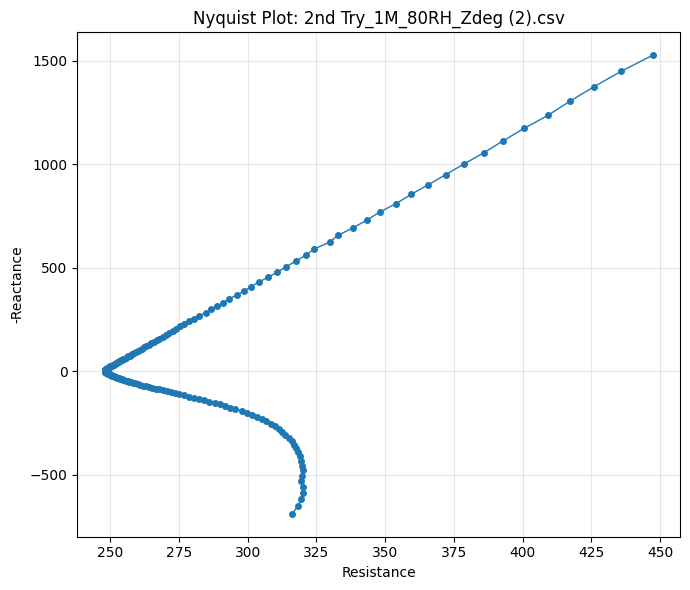

Processing: 2nd Try_1M_80RH_Zdeg (3).csv
  -> 저장 완료: C:\Users\user\Desktop\Gibeom\1. HI Lab\0. Projects\0. On going\3. [Lead] ionic DC-TENG\0. 실험자료\9. Revision\260707_LCR 2차\csv\Zdeg_Nyquist\2nd Try_1M_80RH_Zdeg (3).csv


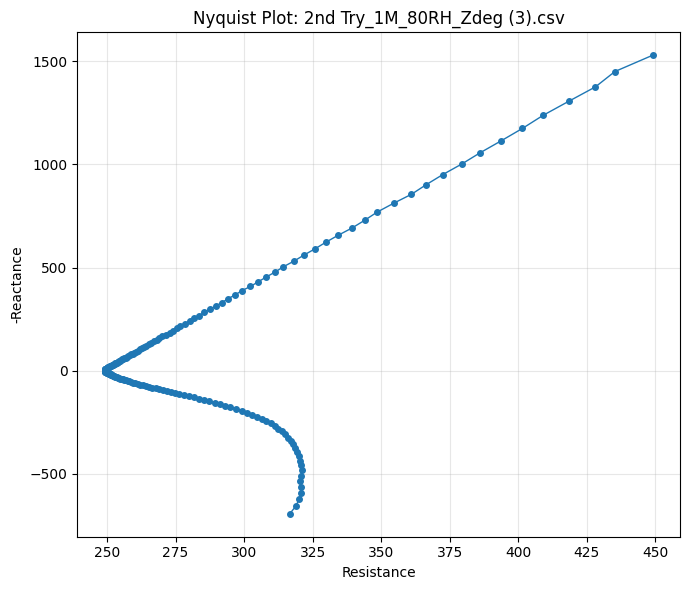

모든 CSV 파일 변환 및 저장이 완료되었습니다.


In [3]:
# ====== 2. 변환된 CSV를 저장할 새 폴더 생성 ======
folder_path = Path(folder_path)
output_folder = folder_path.parent / f"{folder_path.name}_Nyquist"
output_folder.mkdir(exist_ok=True)

csv_files = sorted(folder_path.glob("*.csv"))

if not csv_files:
    raise FileNotFoundError("CSV 파일을 찾지 못했습니다. folder_path를 확인해주세요.")

print(f"원본 폴더: {folder_path}")
print(f"저장 폴더: {output_folder}")
print(f"대상 파일 수: {len(csv_files)}")

# ====== 안전장치: 모든 CSV가 정확히 3열인지 사전 검사 ======
for file_path in csv_files:
    df_check = pd.read_csv(file_path, header=None)

    if df_check.shape[1] != 3:
        raise ValueError(
            f"{file_path.name} -> 열 개수가 {df_check.shape[1]}개입니다. 반드시 3열(Hz, impedance, deg)이어야 합니다."
        )

print("모든 CSV 파일이 3열 형식임을 확인했습니다.\n")

# ====== 4. 각 CSV 파일 변환 및 새 폴더에 저장 ======
for file_path in csv_files:
    print(f"Processing: {file_path.name}")

    df = pd.read_csv(file_path, header=None)

    freq = pd.to_numeric(df.iloc[:, 0], errors="coerce")
    impedance = pd.to_numeric(df.iloc[:, 1], errors="coerce")
    deg = pd.to_numeric(df.iloc[:, 2], errors="coerce")
    rad = np.deg2rad(deg)

    converted_df = pd.DataFrame(
        {
            "Hz": freq,
            "resistance": impedance * np.cos(rad),
            "-reactance": -impedance * np.sin(rad),
        }
    ).dropna()

    if converted_df.empty:
        print("  -> 건너뜀: 유효한 숫자 데이터가 없습니다.")
        continue

    output_path = output_folder / file_path.name
    converted_df.to_csv(output_path, index=False)
    print(f"  -> 저장 완료: {output_path}")

    plot_df = converted_df[
        (converted_df["Hz"] >= freq_min) & (converted_df["Hz"] <= freq_max)
    ]

    if plot_df.empty:
        print(f"  -> Plot 생략: 설정한 주파수 범위({freq_min} Hz ~ {freq_max} Hz)에 해당하는 데이터가 없습니다.")
        continue

    # Support either lowercase or uppercase range variable names from the config cell.
    plot_x_range = globals().get("X_range", x_range)
    plot_y_range = globals().get("Y_range", y_range)

    fig, ax = plt.subplots(figsize=plot_figsize)
    ax.plot(
        plot_df["resistance"],
        plot_df["-reactance"],
        marker="o",
        linestyle="-",
        markersize=4,
        linewidth=1,
    )
    ax.set_xlabel("Resistance")
    ax.set_ylabel("-Reactance")
    if plot_x_range is not None:
        ax.set_xlim(plot_x_range)
    if plot_y_range is not None:
        ax.set_ylim(plot_y_range)
    ax.set_title(f"Nyquist Plot: {file_path.name}")
    ax.grid(True, alpha=0.3)
    # Keep the plot display size fixed even when x/y limits change.
    ax.set_aspect("auto")
    fig.tight_layout()
    plt.show()

print("모든 CSV 파일 변환 및 저장이 완료되었습니다.")